# IEEE 802.11 (WiFi) Wireless Network Simulation — Combined (Final)

| Name              | Roll no | PRN      |
|-------------------|--------|----------|
| Manas Kulkarni    | 311058 | 22311608 |
| Samiksha Nalawade | 311063 | 22311696 |
| Rajlakshmi Desai  | 311065 | 22311732 |
| Shreyash Shabadi  | 311068 | 22420082 |

**Project Guide:** Prof. Rupa Kawchale

---

| Parameter | Value |
|---|---|
| **Stage 1** | Point-to-point WiFi link + 3-node network (3 scenarios) |
| **Stage 2** | 15-node random topology + Rayleigh fading + advanced noise modeling |
| **Standard** | IEEE 802.11b/g/n (2.4 GHz / 5 GHz) |
| **Course** | Wireless Networks (WN PBL) |

---

## 📋 Project Walkthrough

### 🔵 Stage 1 — Basic WiFi Simulation (2-Node → 3-Node)
- **Link Budget & BER** — Indoor log-distance path loss (n=3), SNR calculation, analytical BER for BPSK/QPSK/16-QAM/64-QAM
- **802.11 Rate Adaptation** — All 8 wifi modes tested; highest rate with BER < 1% auto-selected
- **3-Node Network** — AP → STA-1 (relay) → STA-2 across 3 scenarios: normal relay, relay failure (direct 50 m), high interference (+10 dB noise)

### 🔴 Stage 2 — Advanced Simulation (15-Node + Rayleigh Fading)
- **Random Topology** — 15 nodes in 50×50 m area, distances computed from AP to each STA
- **Advanced Channel Model** — Rayleigh fading, frequency-band-aware path loss (2.4 vs 5 GHz), `map_snr_to_throughput` for adaptive mode selection
- **Normal vs War-like Scenarios** — n=3 baseline vs n=4 + +15 dB interference + fading; jammed STAs trigger 5 GHz frequency hop with 1 s penalty
- **Survivability Report** — Connected node count, avg throughput, and % degradation under worst-case conditions
---


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc
import networkx as nx

np.random.seed(42)
print("Libraries loaded")


Libraries loaded


---
# PART 1 — Point-to-Point WiFi Link (IEEE 802.11)

A WiFi access point (AP) sends data to a station (STA) 50 metres away,
through an **indoor** environment (walls, furniture cause extra loss).

```
  [AP] ~~~~ 50 m indoor ~~~~ [STA]
```

### IEEE 802.11 Data Rates & Modulation
| Standard | Modulation | Data Rate | Coding Rate |
|----------|------------|-----------|-------------|
| 802.11b  | BPSK       | 1 Mbps    | 1           |
| 802.11b  | QPSK       | 2 Mbps    | 1           |
| 802.11g  | BPSK 1/2   | 6 Mbps    | 1/2         |
| 802.11g  | QPSK 1/2   | 12 Mbps   | 1/2         |
| 802.11g  | 16-QAM 1/2 | 24 Mbps   | 1/2         |
| 802.11g  | 16-QAM 3/4 | 36 Mbps   | 3/4         |
| 802.11n  | 64-QAM 2/3 | 48 Mbps   | 2/3         |
| 802.11n  | 64-QAM 3/4 | 54 Mbps   | 3/4         |

Higher data rates use complex modulation (more bits per symbol), but are **more sensitive to noise**.

## Step 1 — WiFi System Parameters

In [ ]:
# ── IEEE 802.11 Parameters ──
num_bits       = 10000          # bits to transmit (more = accurate BER)
carrier_freq   = 2.4e9          # 2.4 GHz (WiFi band)
tx_power_dBm   = 20             # 20 dBm = 100 mW (standard WiFi AP)
distance       = 50             # 50 metres (indoor)
c              = 3e8            # speed of light

# ── Indoor Path Loss Model (Log-Distance) ──
# More realistic than free-space for indoor WiFi
# PL = PL_0 + 10 * n * log10(d)
# PL_0 = path loss at 1 metre reference (~40 dB at 2.4 GHz)
# n    = path loss exponent (2=free space, 3=indoor, 4=dense indoor)
PL_0 = 40                       # dB at 1 metre
n_exponent = 3                   # indoor environment

# ── Noise ──
noise_power_dBm = -77           # receiver noise floor (dBm)

print("IEEE 802.11 WiFi Parameters")
print("=" * 40)
print("Frequency     :", carrier_freq/1e9, "GHz")
print("TX Power      :", tx_power_dBm, "dBm (", round(10**(tx_power_dBm/10), 1), "mW )")
print("Distance      :", distance, "m")
print("Environment   : Indoor (n =", n_exponent, ")")
print("Noise Floor   :", noise_power_dBm, "dBm")
print("Bits to send  :", num_bits)

IEEE 802.11 WiFi Parameters
Frequency     : 2.4 GHz
TX Power      : 20 dBm ( 100.0 mW )
Distance      : 50 m
Environment   : Indoor (n = 3 )
Noise Floor   : -77 dBm
Bits to send  : 10000


## Step 2 — Indoor Path Loss Model

Unlike free-space, indoor environments have walls, furniture, and reflections.  
We use the **Log-Distance Path Loss Model:**

$$PL(d) = PL_0 + 10 \cdot n \cdot \log_{10}(d)$$

| Environment | Path Loss Exponent (n) |
|---|---|
| Free Space | 2 |
| Indoor (office) | **3** |
| Dense Indoor | 4-6 |

For comparison, we also compute **Free-Space Path Loss (FSPL)**.

In [ ]:
# Indoor Log-Distance Path Loss
path_loss_indoor_dB = PL_0 + 10 * n_exponent * np.log10(distance)

# Free-Space Path Loss (for comparison)
path_loss_free_dB = (20 * np.log10(distance)
                   + 20 * np.log10(carrier_freq)
                   + 20 * np.log10(4 * np.pi / c))

wavelength = c / carrier_freq

print("Wavelength         :", round(wavelength*100, 2), "cm")
print("Free-Space PL      :", round(path_loss_free_dB, 2), "dB")
print("Indoor PL (n=3)    :", round(path_loss_indoor_dB, 2), "dB")
print("Extra indoor loss  :", round(path_loss_indoor_dB - path_loss_free_dB, 2), "dB")

Wavelength         : 12.5 cm
Free-Space PL      : 74.03 dB
Indoor PL (n=3)    : 90.97 dB
Extra indoor loss  : 16.94 dB


## Step 3 — Received Power & SNR
$$\text{RX Power} = \text{TX Power} - \text{Path Loss}_{\text{indoor}}$$
$$\text{SNR (dB)} = \text{RX Power} - \text{Noise Floor}$$

In [ ]:
rx_power_dBm = tx_power_dBm - path_loss_indoor_dB
snr_dB       = rx_power_dBm - noise_power_dBm
snr_linear   = 10 ** (snr_dB / 10)

print("TX Power     :", tx_power_dBm, "dBm")
print("Path Loss    :", round(path_loss_indoor_dB, 2), "dB")
print("RX Power     :", round(rx_power_dBm, 2), "dBm")
print("Noise Floor  :", noise_power_dBm, "dBm")
print("SNR          :", round(snr_dB, 2), "dB")
print("SNR (linear) :", round(snr_linear, 2))

TX Power     : 20 dBm
Path Loss    : 90.97 dB
RX Power     : -70.97 dBm
Noise Floor  : -77 dBm
SNR          : 6.03 dB
SNR (linear) : 4.01


## Step 4 — BER Formulas for Each Modulation

Each modulation scheme has a different BER formula:

| Modulation | BER Formula |
|---|---|
| BPSK | $\frac{1}{2} \cdot \text{erfc}(\sqrt{\text{SNR}})$ |
| QPSK | $\frac{1}{2} \cdot \text{erfc}(\sqrt{\text{SNR}})$ (same as BPSK per bit) |
| 16-QAM | $\frac{3}{8} \cdot \text{erfc}\left(\sqrt{\frac{2 \cdot \text{SNR}}{5}}\right)$ |
| 64-QAM | $\frac{7}{24} \cdot \text{erfc}\left(\sqrt{\frac{\text{SNR}}{7}}\right)$ |

**Key insight:** Higher-order modulation (64-QAM) carries more data but needs higher SNR to work correctly.

In [ ]:
def ber_bpsk(snr_lin):
    """BER for BPSK modulation."""
    return 0.5 * erfc(np.sqrt(snr_lin))

def ber_qpsk(snr_lin):
    """BER for QPSK (same as BPSK per bit)."""
    return 0.5 * erfc(np.sqrt(snr_lin))

def ber_16qam(snr_lin):
    """BER for 16-QAM."""
    return (3.0/8) * erfc(np.sqrt(snr_lin * 2.0/5))

def ber_64qam(snr_lin):
    """BER for 64-QAM."""
    return (7.0/24) * erfc(np.sqrt(snr_lin / 7.0))

print("BER functions defined")
print("At current SNR =", round(snr_dB, 2), "dB :")
print("  BPSK   BER =", round(ber_bpsk(snr_linear), 6))
print("  QPSK   BER =", round(ber_qpsk(snr_linear), 6))
print("  16-QAM BER =", round(ber_16qam(snr_linear), 6))
print("  64-QAM BER =", round(ber_64qam(snr_linear), 6))

BER functions defined
At current SNR = 6.03 dB :
  BPSK   BER = 0.002314
  QPSK   BER = 0.002314
  16-QAM BER = 0.027486
  64-QAM BER = 0.082973


## Step 5 — Transmission Simulator
This function simulates sending bits using any modulation scheme over a noisy channel.

In [ ]:
def transmit(bits, snr_dB_value, modulation='BPSK'):
    """
    Simulate wireless transmission.
    bits       : array of 0s and 1s
    snr_dB     : signal-to-noise ratio in dB
    modulation : 'BPSK', 'QPSK', '16-QAM', or '64-QAM'
    Returns    : (received_bits, errors, BER)
    """
    snr_lin = 10 ** (snr_dB_value / 10)

    # Get theoretical BER for this modulation
    if modulation == 'BPSK':    p_error = ber_bpsk(snr_lin)
    elif modulation == 'QPSK':  p_error = ber_qpsk(snr_lin)
    elif modulation == '16-QAM': p_error = ber_16qam(snr_lin)
    elif modulation == '64-QAM': p_error = ber_64qam(snr_lin)
    else: p_error = ber_bpsk(snr_lin)

    # Simulate: flip each bit with probability = p_error
    # This is equivalent to full modulate → noise → demodulate
    error_mask = np.random.random(len(bits)) < p_error
    rx_bits = bits.copy()
    rx_bits[error_mask] = 1 - rx_bits[error_mask]  # flip errored bits

    errors = np.sum(bits != rx_bits)
    return rx_bits, errors, errors / len(bits)

print("Transmit function defined")

Transmit function defined


## Step 6 — IEEE 802.11 Data Rate Analysis
We simulate ALL 802.11 data rates at our current SNR to see which ones work and which fail.

In [ ]:
# IEEE 802.11 modes: (standard, modulation, data_rate_Mbps)
wifi_modes = [
    ('802.11b', 'BPSK',    1),
    ('802.11b', 'QPSK',    2),
    ('802.11g', 'BPSK',    6),
    ('802.11g', 'QPSK',   12),
    ('802.11g', '16-QAM', 24),
    ('802.11g', '16-QAM', 36),
    ('802.11n', '64-QAM', 48),
    ('802.11n', '64-QAM', 54),
]

tx_bits = np.random.randint(0, 2, num_bits)

print("IEEE 802.11 Data Rate Analysis at SNR =", round(snr_dB, 2), "dB")
print("=" * 80)
print("Standard  Modulation  DataRate    BER        Throughput   Success%   Status")
print("-" * 80)

results = []
for std, mod, rate in wifi_modes:
    rx_bits, errs, ber = transmit(tx_bits, snr_dB, mod)
    tp = rate * (1 - ber)          # effective throughput
    success = (1 - ber) * 100

    # WiFi status based on BER thresholds
    if ber < 0.001:   status = 'EXCELLENT'
    elif ber < 0.01:  status = 'GOOD'
    elif ber < 0.05:  status = 'USABLE'
    else:             status = 'TOO HIGH'

    results.append((std, mod, rate, ber, tp, success, status))
    print(std.ljust(10), mod.ljust(10), str(rate).ljust(8), 'Mbps',
          str(round(ber,6)).ljust(12),
          str(round(tp,2)).ljust(10), 'Mbps',
          str(round(success,2)).ljust(8) + '%',
          status)

IEEE 802.11 Data Rate Analysis at SNR = 6.03 dB
Standard  Modulation  DataRate    BER        Throughput   Success%   Status
--------------------------------------------------------------------------------
802.11b    BPSK       1        Mbps 0.002        1.0        Mbps 99.8    % GOOD
802.11b    QPSK       2        Mbps 0.002        2.0        Mbps 99.8    % GOOD
802.11g    BPSK       6        Mbps 0.0021       5.99       Mbps 99.79   % GOOD
802.11g    QPSK       12       Mbps 0.0027       11.97      Mbps 99.73   % GOOD
802.11g    16-QAM     24       Mbps 0.0296       23.29      Mbps 97.04   % USABLE
802.11g    16-QAM     36       Mbps 0.0262       35.06      Mbps 97.38   % USABLE
802.11n    64-QAM     48       Mbps 0.079        44.21      Mbps 92.1    % TOO HIGH
802.11n    64-QAM     54       Mbps 0.0832       49.51      Mbps 91.68   % TOO HIGH


## Step 7 — Adaptive Rate Selection
WiFi automatically picks the **highest data rate** that still has acceptable BER (< 1%).  
This is how 802.11 Rate Adaptation works in real WiFi.

In [ ]:
# Find the best usable rate (highest throughput with BER < 1%)
usable = [(r[2], r[4], r[0], r[1], r[3]) for r in results if r[3] < 0.01]

if usable:
    best = max(usable, key=lambda x: x[1])  # highest throughput
    print("WiFi Rate Adaptation Result:")
    print("  Best Standard  :", best[2])
    print("  Best Modulation:", best[3])
    print("  Data Rate      :", best[0], "Mbps")
    print("  Actual Throughput:", round(best[1], 2), "Mbps")
    print("  BER            :", round(best[4], 6))
else:
    print("No usable data rate at this SNR! Signal too weak.")

WiFi Rate Adaptation Result:
  Best Standard  : 802.11g
  Best Modulation: QPSK
  Data Rate      : 12 Mbps
  Actual Throughput: 11.97 Mbps
  BER            : 0.0027


## Step 8 — BER vs SNR Curve (Classic 802.11 Analysis)
This is the most important plot in wireless communications.  
It shows how BER changes with SNR for each modulation.

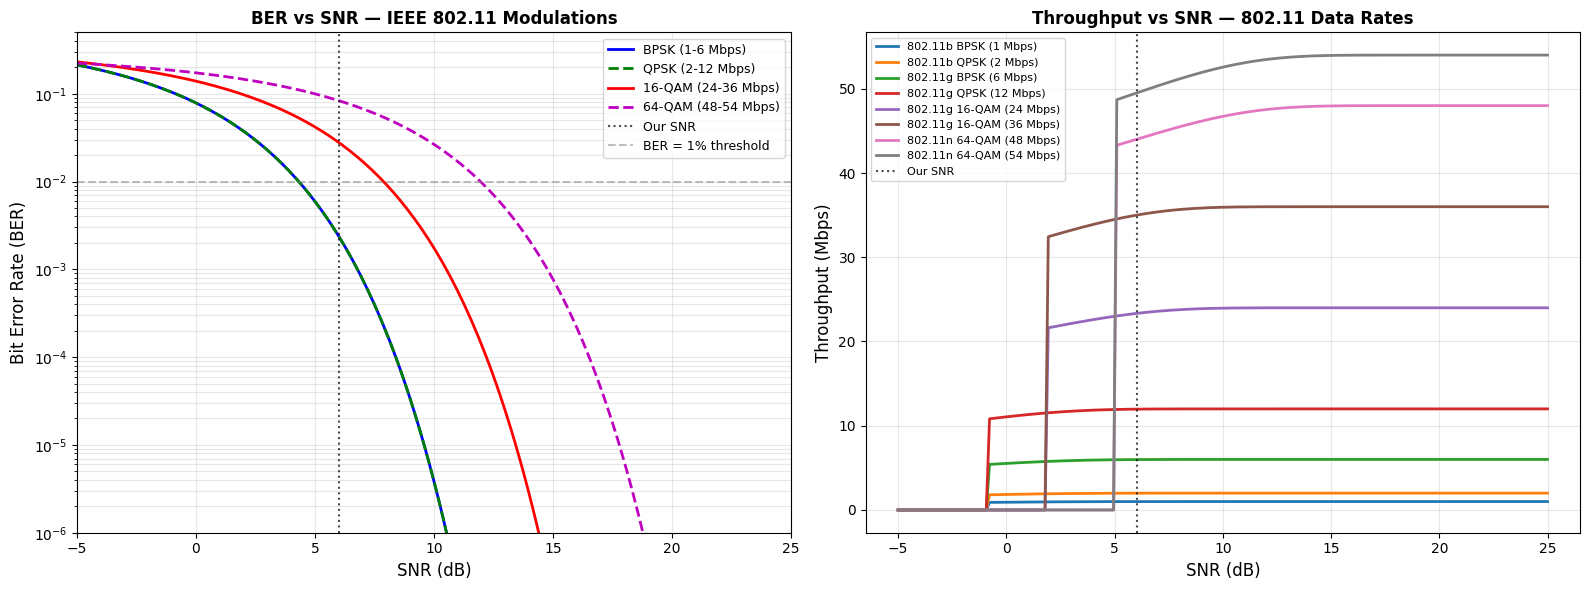

In [ ]:
snr_range_dB = np.linspace(-5, 25, 200)
snr_range_lin = 10 ** (snr_range_dB / 10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: BER vs SNR ──
ax = axes[0]
ax.semilogy(snr_range_dB, ber_bpsk(snr_range_lin), 'b-', lw=2, label='BPSK (1-6 Mbps)')
ax.semilogy(snr_range_dB, ber_qpsk(snr_range_lin), 'g--', lw=2, label='QPSK (2-12 Mbps)')
ax.semilogy(snr_range_dB, ber_16qam(snr_range_lin), 'r-', lw=2, label='16-QAM (24-36 Mbps)')
ax.semilogy(snr_range_dB, ber_64qam(snr_range_lin), 'm--', lw=2, label='64-QAM (48-54 Mbps)')

# Mark our current operating point
ax.axvline(x=snr_dB, color='black', ls=':', alpha=0.7, label='Our SNR')
ax.axhline(y=0.01, color='gray', ls='--', alpha=0.5, label='BER = 1% threshold')

ax.set_xlabel('SNR (dB)', fontsize=12)
ax.set_ylabel('Bit Error Rate (BER)', fontsize=12)
ax.set_title('BER vs SNR — IEEE 802.11 Modulations', fontweight='bold')
ax.set_ylim(1e-6, 0.5)
ax.set_xlim(-5, 25)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which='both')

# ── Plot 2: Throughput vs SNR ──
ax = axes[1]
for std, mod, rate in wifi_modes:
    if mod == 'BPSK':    ber_curve = ber_bpsk(snr_range_lin)
    elif mod == 'QPSK':  ber_curve = ber_qpsk(snr_range_lin)
    elif mod == '16-QAM': ber_curve = ber_16qam(snr_range_lin)
    else:                 ber_curve = ber_64qam(snr_range_lin)
    tp_curve = rate * (1 - ber_curve)
    tp_curve[ber_curve > 0.1] = 0   # unusable above 10% BER
    label = std + ' ' + mod + ' (' + str(rate) + ' Mbps)'
    ax.plot(snr_range_dB, tp_curve, lw=2, label=label)

ax.axvline(x=snr_dB, color='black', ls=':', alpha=0.7, label='Our SNR')
ax.set_xlabel('SNR (dB)', fontsize=12)
ax.set_ylabel('Throughput (Mbps)', fontsize=12)
ax.set_title('Throughput vs SNR — 802.11 Data Rates', fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 9 — Signal Visualization (BPSK at 50 m)
Signal before and after noise

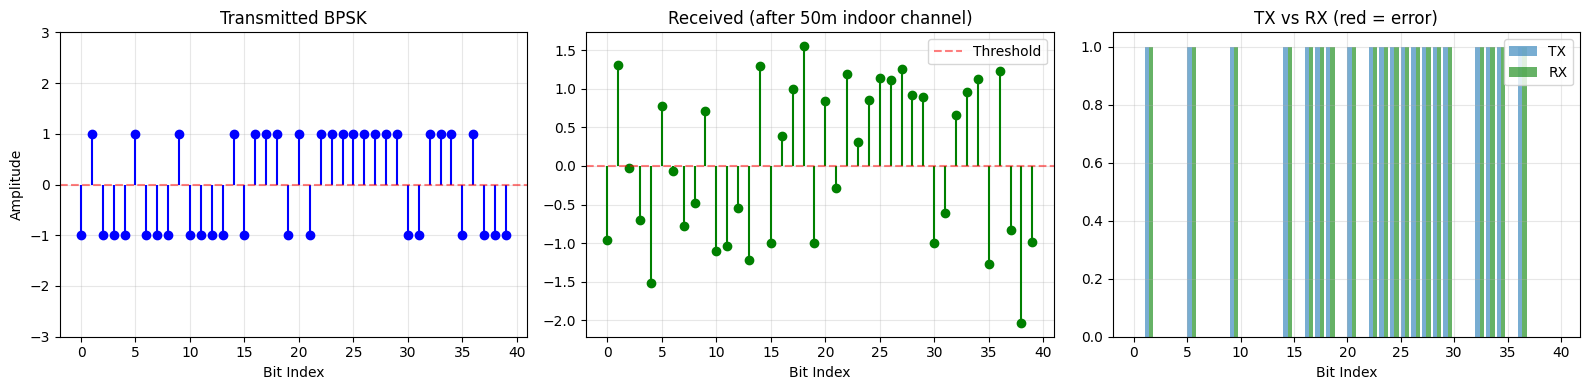

In [ ]:
# For visualization, do a full BPSK simulation with actual signal + noise
N_show = 40  # bits to display
bpsk_signal = 2 * tx_bits[:N_show] - 1
noise_std = np.sqrt(1.0 / snr_linear)
noise = np.random.normal(0, noise_std, N_show)
rx_signal = bpsk_signal + noise
rx_detected = (rx_signal > 0).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].stem(range(N_show), bpsk_signal, linefmt='b-', markerfmt='bo', basefmt=' ')
axes[0].axhline(0, color='red', ls='--', alpha=0.5)
axes[0].set_title('Transmitted BPSK')
axes[0].set_xlabel('Bit Index')
axes[0].set_ylabel('Amplitude')
axes[0].set_ylim(-3, 3)
axes[0].grid(alpha=0.3)

axes[1].stem(range(N_show), rx_signal, linefmt='g-', markerfmt='go', basefmt=' ')
axes[1].axhline(0, color='red', ls='--', alpha=0.5, label='Threshold')
axes[1].set_title('Received (after 50m indoor channel)')
axes[1].set_xlabel('Bit Index')
axes[1].legend()
axes[1].grid(alpha=0.3)

err_colors = ['green' if tx_bits[i]==rx_detected[i] else 'red' for i in range(N_show)]
axes[2].bar(range(N_show), tx_bits[:N_show], width=0.4, align='edge', label='TX', alpha=0.6)
axes[2].bar([x+0.4 for x in range(N_show)], rx_detected, width=0.4, align='edge',
            label='RX', alpha=0.6, color=err_colors)
axes[2].set_title('TX vs RX (red = error)')
axes[2].set_xlabel('Bit Index')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 10 — Data Rate vs Throughput Comparison

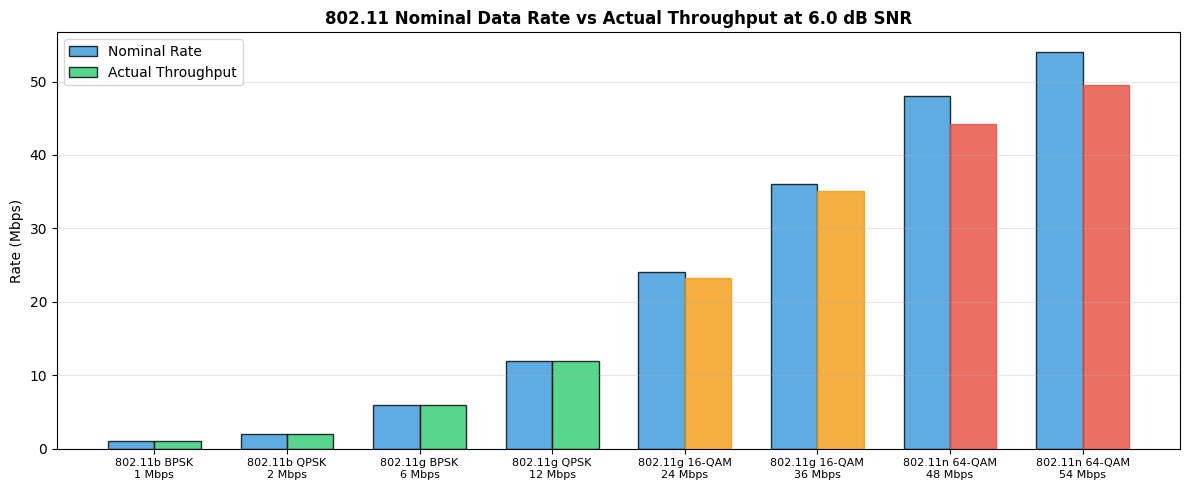

Green = good (BER<1%)  |  Orange = marginal (1-5%)  |  Red = unusable (>5%)


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

labels = [r[0]+' '+r[1]+'\n'+str(r[2])+' Mbps' for r in results]
nominal = [r[2] for r in results]
actual  = [r[4] for r in results]
x = np.arange(len(labels))
w = 0.35

bars1 = ax.bar(x-w/2, nominal, w, label='Nominal Rate', color='#3498db', edgecolor='black', alpha=0.8)
bars2 = ax.bar(x+w/2, actual, w,  label='Actual Throughput', color='#2ecc71', edgecolor='black', alpha=0.8)

# Color actual bars red if BER too high
for i, r in enumerate(results):
    if r[3] >= 0.05:
        bars2[i].set_color('#e74c3c')
    elif r[3] >= 0.01:
        bars2[i].set_color('#f39c12')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Rate (Mbps)')
ax.set_title('802.11 Nominal Data Rate vs Actual Throughput at ' + str(round(snr_dB,1)) + ' dB SNR',
             fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Green = good (BER<1%)  |  Orange = marginal (1-5%)  |  Red = unusable (>5%)")

---
# PART 2 — 3-Node WiFi Network
An Access Point (AP) sends data to a far Station (STA-2) via a Relay (STA-1).

```
  [AP] ---25 m--- [STA-1 Relay] ---25 m--- [STA-2 Dest]
```

**3 Scenarios:**
1. Normal relay — AP → STA-1 → STA-2
2. Relay fails — direct AP → STA-2 (50 m)
3. High interference — +10 dB more noise

## Step 11 — Define Network Nodes

In [ ]:
nodes = {
    "AP":    (0,  0),    # Access Point (source)
    "STA-1": (25, 0),    # Relay station
    "STA-2": (50, 0),    # Destination station
}

print("AP    (Access Point)  :", nodes["AP"])
print("STA-1 (Relay)         :", nodes["STA-1"])
print("STA-2 (Destination)   :", nodes["STA-2"])

AP    (Access Point)  : (0, 0)
STA-1 (Relay)         : (25, 0)
STA-2 (Destination)   : (50, 0)


## Step 12 — Helper Functions

In [ ]:
def get_distance(pos1, pos2):
    """Distance between two points."""
    return np.sqrt((pos1[0]-pos2[0])**2 + (pos1[1]-pos2[1])**2)


def get_indoor_path_loss(dist):
    """Indoor log-distance path loss."""
    return PL_0 + 10 * n_exponent * np.log10(dist)


def get_snr(dist):
    """Get SNR in dB for a given distance."""
    pl  = get_indoor_path_loss(dist)
    rx  = tx_power_dBm - pl
    snr = rx - noise_power_dBm
    return snr, pl, rx

print("Functions defined")

Functions defined


## Step 13 — Link Budgets

In [ ]:
link_pairs = {"AP-STA1": ("AP","STA-1"), "STA1-STA2": ("STA-1","STA-2"), "AP-STA2": ("AP","STA-2")}

link_info = {}
for name, (src, dst) in link_pairs.items():
    d = get_distance(nodes[src], nodes[dst])
    snr_val, pl, rx = get_snr(d)
    link_info[name] = {"dist": d, "pl": pl, "rx": rx, "snr": snr_val}

print("Link          Dist(m)  PathLoss(dB)  RX(dBm)    SNR(dB)")
print("-" * 60)
for name, info in link_info.items():
    print(name.ljust(14),
          str(round(info["dist"])).ljust(9),
          str(round(info["pl"], 2)).ljust(14),
          str(round(info["rx"], 2)).ljust(11),
          round(info["snr"], 2))

Link          Dist(m)  PathLoss(dB)  RX(dBm)    SNR(dB)
------------------------------------------------------------
AP-STA1        25        81.94          -61.94      15.06
STA1-STA2      25        81.94          -61.94      15.06
AP-STA2        50        90.97          -70.97      6.03


## Scenario 1 — Normal Relay (AP → STA-1 → STA-2)
Using 16-QAM (24 Mbps 802.11g) for the relay hops.

In [ ]:
mod_relay = '16-QAM'
rate_relay = 24  # Mbps
data = np.random.randint(0, 2, num_bits)

# Hop 1: AP to STA-1 (25 m)
rx_at_sta1, err1, ber1 = transmit(data, link_info["AP-STA1"]["snr"], mod_relay)
print("Hop AP -> STA-1 (", mod_relay, rate_relay, "Mbps )")
print("  Distance:", int(link_info["AP-STA1"]["dist"]), "m")
print("  SNR     :", round(link_info["AP-STA1"]["snr"], 2), "dB")
print("  Errors  :", err1, " |  BER:", round(ber1, 6))

# Hop 2: STA-1 forwards to STA-2 (25 m)
rx_at_sta2, err2, ber2 = transmit(rx_at_sta1, link_info["STA1-STA2"]["snr"], mod_relay)
print()
print("Hop STA-1 -> STA-2 (", mod_relay, rate_relay, "Mbps )")
print("  Distance:", int(link_info["STA1-STA2"]["dist"]), "m")
print("  SNR     :", round(link_info["STA1-STA2"]["snr"], 2), "dB")
print("  Errors  :", err2, " |  BER:", round(ber2, 6))

# End-to-end
e2e_err_s1 = np.sum(data != rx_at_sta2)
ber_s1 = e2e_err_s1 / num_bits
tp_s1  = rate_relay * (1 - ber_s1)
print()
print("End-to-End:")
print("  Errors    :", e2e_err_s1)
print("  BER       :", round(ber_s1, 6))
print("  Throughput:", round(tp_s1, 2), "Mbps (out of", rate_relay, "Mbps)")

Hop AP -> STA-1 ( 16-QAM 24 Mbps )
  Distance: 25 m
  SNR     : 15.06 dB
  Errors  : 0  |  BER: 0.0

Hop STA-1 -> STA-2 ( 16-QAM 24 Mbps )
  Distance: 25 m
  SNR     : 15.06 dB
  Errors  : 0  |  BER: 0.0

End-to-End:
  Errors    : 0
  BER       : 0.0
  Throughput: 24.0 Mbps (out of 24 Mbps)


## Scenario 2 — Relay Failed (Direct AP → STA-2)
STA-1 is down. Signal travels full 50 m. WiFi must use a lower data rate.

In [ ]:
# At 50m, SNR is lower, so WiFi would drop to a lower rate
# Let's try multiple rates and see which works
data2 = np.random.randint(0, 2, num_bits)
snr_direct = link_info["AP-STA2"]["snr"]

print("Direct AP -> STA-2 at", int(link_info["AP-STA2"]["dist"]), "m")
print("SNR:", round(snr_direct, 2), "dB")
print()

# Test all rates at direct distance
print("Rate selection for direct path:")
best_tp_s2 = 0
best_rate_s2 = ''
ber_s2 = 0
for std, mod, rate in wifi_modes:
    _, errs, ber = transmit(data2, snr_direct, mod)
    tp = rate * (1 - ber)
    tag = ' <-- BEST' if ber < 0.01 and tp > best_tp_s2 else ''
    if ber < 0.01 and tp > best_tp_s2:
        best_tp_s2 = tp
        best_rate_s2 = std + ' ' + mod + ' ' + str(rate)
        ber_s2 = ber
        e2e_err_s2 = errs
    status = 'OK' if ber < 0.01 else 'HIGH BER'
    print(' ', std.ljust(8), mod.ljust(8), str(rate).ljust(4), 'Mbps  BER='+str(round(ber,6)).ljust(10),
          'TP='+str(round(tp,2)).ljust(8), status + tag)

tp_s2 = best_tp_s2
print()
print("WiFi selects:", best_rate_s2)
print("Throughput  :", round(tp_s2, 2), "Mbps")

Direct AP -> STA-2 at 50 m
SNR: 6.03 dB

Rate selection for direct path:
  802.11b  BPSK     1    Mbps  BER=0.0023     TP=1.0      OK <-- BEST
  802.11b  QPSK     2    Mbps  BER=0.0026     TP=1.99     OK <-- BEST
  802.11g  BPSK     6    Mbps  BER=0.0021     TP=5.99     OK <-- BEST
  802.11g  QPSK     12   Mbps  BER=0.0017     TP=11.98    OK <-- BEST
  802.11g  16-QAM   24   Mbps  BER=0.0238     TP=23.43    HIGH BER
  802.11g  16-QAM   36   Mbps  BER=0.0275     TP=35.01    HIGH BER
  802.11n  64-QAM   48   Mbps  BER=0.0832     TP=44.01    HIGH BER
  802.11n  64-QAM   54   Mbps  BER=0.0828     TP=49.53    HIGH BER

WiFi selects: 802.11g QPSK 12
Throughput  : 11.98 Mbps


## Scenario 3 — High Interference (+10 dB noise)
All nodes active, but nearby microwave/Bluetooth causes +10 dB interference.

In [ ]:
noise_power_weak = -67   # 10 dB worse than -77
print("Normal noise:", noise_power_dBm, "dBm")
print("Weak noise:  ", noise_power_weak, "dBm  (+10 dB interference)")
print()

# Recalculate SNR under interference
snr_weak = {}
for name, info in link_info.items():
    snr_weak[name] = info["rx"] - noise_power_weak
    print(name.ljust(14), "Normal SNR:", round(info["snr"],2), "dB  ->  Weak SNR:", round(snr_weak[name],2), "dB")

data3 = np.random.randint(0, 2, num_bits)

# Hop 1
rx_at_sta1_w, err1_w, ber1_w = transmit(data3, snr_weak["AP-STA1"], mod_relay)
print()
print("Hop AP -> STA-1:", err1_w, "errors  BER:", round(ber1_w, 6))

# Hop 2
rx_at_sta2_w, err2_w, ber2_w = transmit(rx_at_sta1_w, snr_weak["STA1-STA2"], mod_relay)
print("Hop STA1 -> STA2:", err2_w, "errors  BER:", round(ber2_w, 6))

# End-to-end
e2e_err_s3 = np.sum(data3 != rx_at_sta2_w)
ber_s3 = e2e_err_s3 / num_bits
tp_s3  = rate_relay * (1 - ber_s3)
print()
print("End-to-End:  Errors:", e2e_err_s3, " BER:", round(ber_s3, 6), " Throughput:", round(tp_s3, 2), "Mbps")

Normal noise: -77 dBm
Weak noise:   -67 dBm  (+10 dB interference)

AP-STA1        Normal SNR: 15.06 dB  ->  Weak SNR: 5.06 dB
STA1-STA2      Normal SNR: 15.06 dB  ->  Weak SNR: 5.06 dB
AP-STA2        Normal SNR: 6.03 dB  ->  Weak SNR: -3.97 dB

Hop AP -> STA-1: 419 errors  BER: 0.0419
Hop STA1 -> STA2: 397 errors  BER: 0.0397

End-to-End:  Errors: 796  BER: 0.0796  Throughput: 22.09 Mbps


## Comparison Table

In [ ]:
print("Scenario                       Errors   BER        Throughput    Status")
print("=" * 75)

def quality(ber):
    if ber < 0.001: return 'EXCELLENT'
    if ber < 0.01:  return 'GOOD'
    if ber < 0.05:  return 'USABLE'
    return 'POOR'

print("1. Normal Relay (16-QAM 24M)  ",
      str(e2e_err_s1).ljust(9),
      str(round(ber_s1,6)).ljust(11),
      str(round(tp_s1,2)).ljust(8),'Mbps   ',
      quality(ber_s1))

print("2. Relay Failed (rate adapt)  ",
      str(e2e_err_s2).ljust(9),
      str(round(ber_s2,6)).ljust(11),
      str(round(tp_s2,2)).ljust(8),'Mbps   ',
      quality(ber_s2))

print("3. High Interference (+10dB)  ",
      str(e2e_err_s3).ljust(9),
      str(round(ber_s3,6)).ljust(11),
      str(round(tp_s3,2)).ljust(8),'Mbps   ',
      quality(ber_s3))

Scenario                       Errors   BER        Throughput    Status
1. Normal Relay (16-QAM 24M)   0         0.0         24.0     Mbps    EXCELLENT
2. Relay Failed (rate adapt)   17        0.0017      11.98    Mbps    GOOD
3. High Interference (+10dB)   796       0.0796      22.09    Mbps    POOR


## Final Visualization — Network Graphs & Performance

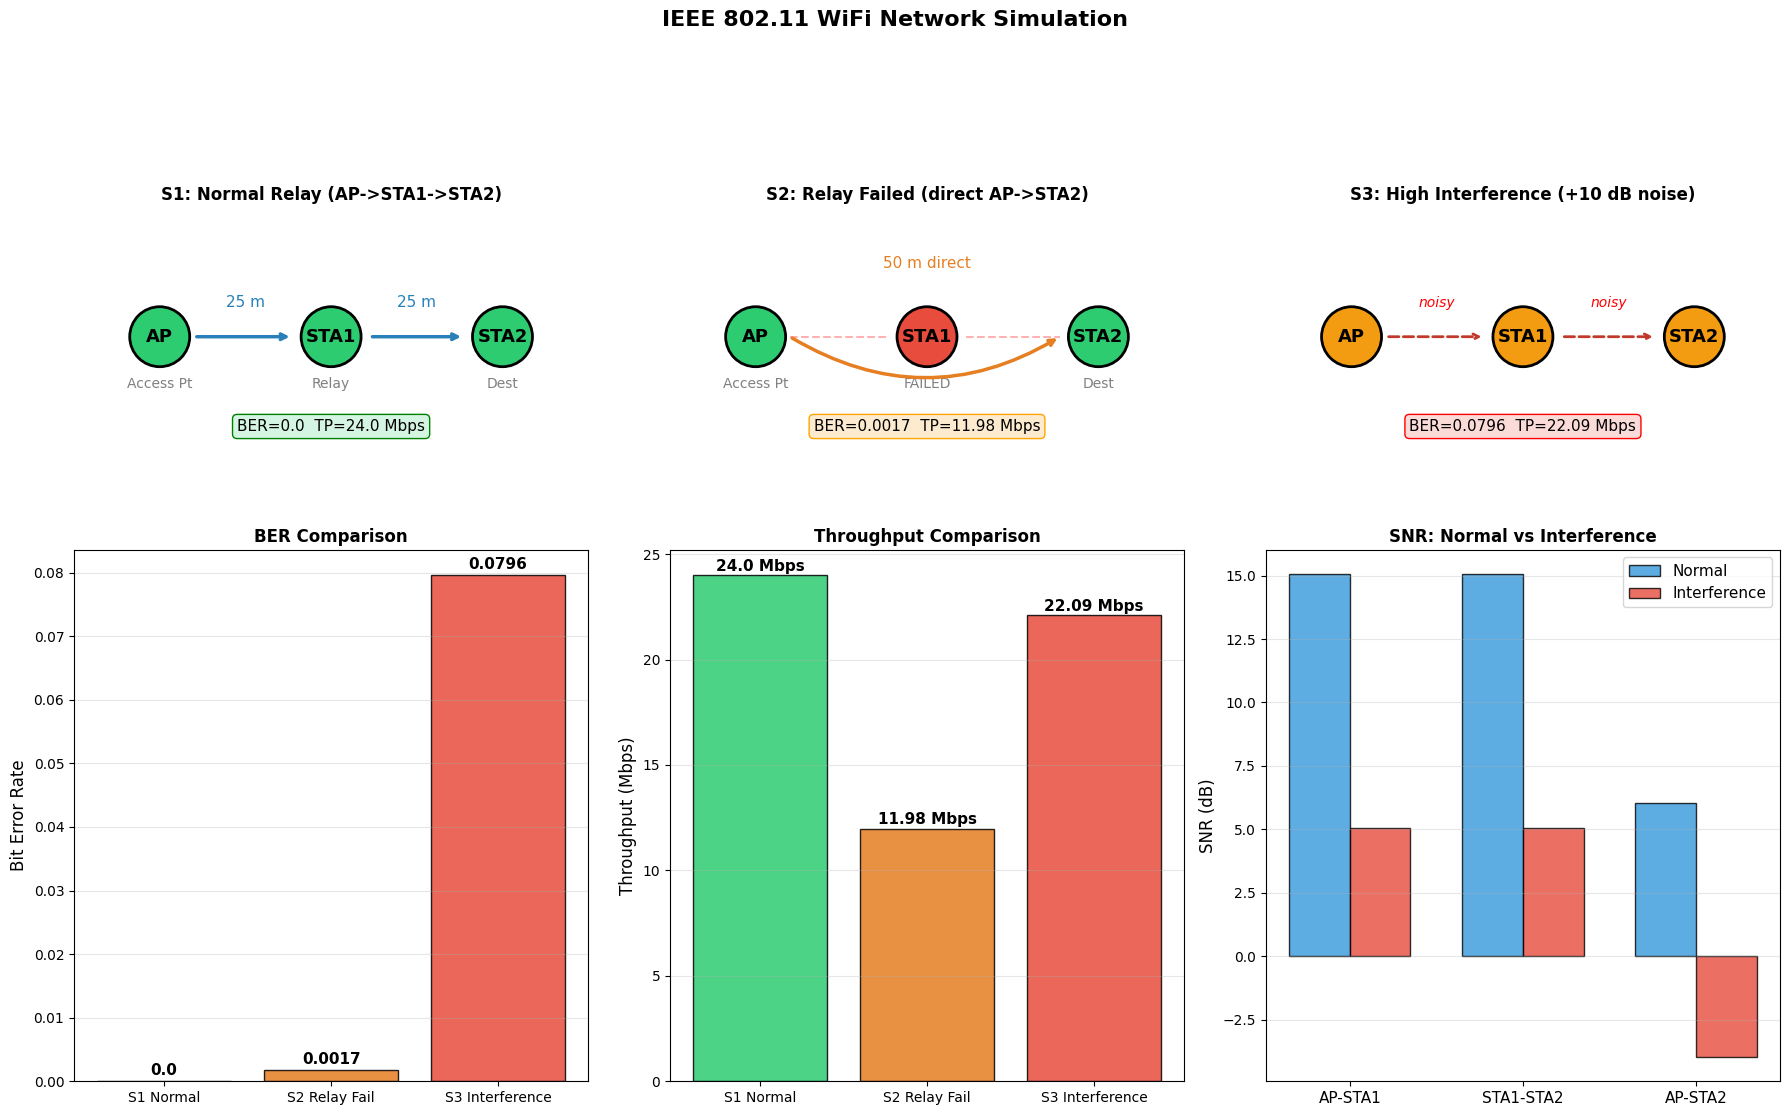

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

def draw_node(ax, x, y, label, color='#2ecc71', sublabel=''):
    circle = plt.Circle((x,y), 0.35, color=color, ec='black', lw=2, zorder=5)
    ax.add_patch(circle)
    ax.text(x, y, label, ha='center', va='center', fontsize=13, fontweight='bold', zorder=6)
    if sublabel:
        ax.text(x, y-0.6, sublabel, ha='center', fontsize=10, color='gray')

def setup_ax(ax):
    ax.set_xlim(-1, 5); ax.set_ylim(-1.5, 1.5); ax.set_aspect('equal'); ax.axis('off')

# ── Scenario 1: Normal ──
ax = axes[0, 0]
ax.set_title('S1: Normal Relay (AP->STA1->STA2)', fontweight='bold', fontsize=12)
draw_node(ax, 0, 0, 'AP', sublabel='Access Pt')
draw_node(ax, 2, 0, 'STA1', sublabel='Relay')
draw_node(ax, 4, 0, 'STA2', sublabel='Dest')
ax.annotate('', xy=(1.55,0), xytext=(0.4,0), arrowprops=dict(arrowstyle='->', color='#2980b9', lw=2.5))
ax.annotate('', xy=(3.55,0), xytext=(2.45,0), arrowprops=dict(arrowstyle='->', color='#2980b9', lw=2.5))
ax.text(1.0, 0.35, '25 m', ha='center', fontsize=11, color='#2980b9')
ax.text(3.0, 0.35, '25 m', ha='center', fontsize=11, color='#2980b9')
lbl1 = 'BER=' + str(round(ber_s1,6)) + '  TP=' + str(round(tp_s1,2)) + ' Mbps'
ax.text(2.0, -1.1, lbl1, ha='center', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='#d5f5e3', edgecolor='green'))
setup_ax(ax)

# ── Scenario 2: Relay Failed ──
ax = axes[0, 1]
ax.set_title('S2: Relay Failed (direct AP->STA2)', fontweight='bold', fontsize=12)
draw_node(ax, 0, 0, 'AP', sublabel='Access Pt')
draw_node(ax, 2, 0, 'STA1', color='#e74c3c', sublabel='FAILED')
draw_node(ax, 4, 0, 'STA2', sublabel='Dest')
ax.annotate('', xy=(3.55,0), xytext=(0.4,0),
            arrowprops=dict(arrowstyle='->', color='#e67e22', lw=2.5, connectionstyle='arc3,rad=0.3'))
ax.text(2.0, 0.8, '50 m direct', ha='center', fontsize=11, color='#e67e22')
ax.plot([0.4,1.55], [0,0], 'r--', alpha=0.3)
ax.plot([2.45,3.55], [0,0], 'r--', alpha=0.3)
lbl2 = 'BER=' + str(round(ber_s2,6)) + '  TP=' + str(round(tp_s2,2)) + ' Mbps'
ax.text(2.0, -1.1, lbl2, ha='center', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='#fdebd0', edgecolor='orange'))
setup_ax(ax)

# ── Scenario 3: Interference ──
ax = axes[0, 2]
ax.set_title('S3: High Interference (+10 dB noise)', fontweight='bold', fontsize=12)
draw_node(ax, 0, 0, 'AP', color='#f39c12')
draw_node(ax, 2, 0, 'STA1', color='#f39c12')
draw_node(ax, 4, 0, 'STA2', color='#f39c12')
ax.annotate('', xy=(1.55,0), xytext=(0.4,0), arrowprops=dict(arrowstyle='->', color='#c0392b', lw=2, ls='--'))
ax.annotate('', xy=(3.55,0), xytext=(2.45,0), arrowprops=dict(arrowstyle='->', color='#c0392b', lw=2, ls='--'))
ax.text(1.0, 0.35, 'noisy', ha='center', fontsize=10, color='red', style='italic')
ax.text(3.0, 0.35, 'noisy', ha='center', fontsize=10, color='red', style='italic')
lbl3 = 'BER=' + str(round(ber_s3,6)) + '  TP=' + str(round(tp_s3,2)) + ' Mbps'
ax.text(2.0, -1.1, lbl3, ha='center', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='#fadbd8', edgecolor='red'))
setup_ax(ax)

# ── BER Bar Chart ──
ax = axes[1, 0]
sc_names = ['S1 Normal', 'S2 Relay Fail', 'S3 Interference']
sc_bers = [ber_s1, ber_s2, ber_s3]
sc_colors = ['#2ecc71', '#e67e22', '#e74c3c']
bars = ax.bar(sc_names, sc_bers, color=sc_colors, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, sc_bers):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            str(round(val,6)), ha='center', fontweight='bold', fontsize=11)
ax.set_ylabel('Bit Error Rate', fontsize=12)
ax.set_title('BER Comparison', fontweight='bold', fontsize=12)
ax.grid(axis='y', alpha=0.3)

# ── Throughput Bar Chart ──
ax = axes[1, 1]
sc_tps = [tp_s1, tp_s2, tp_s3]
bars = ax.bar(sc_names, sc_tps, color=sc_colors, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, sc_tps):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            str(round(val,2))+' Mbps', ha='center', fontweight='bold', fontsize=11)
ax.set_ylabel('Throughput (Mbps)', fontsize=12)
ax.set_title('Throughput Comparison', fontweight='bold', fontsize=12)
ax.grid(axis='y', alpha=0.3)

# ── SNR Normal vs Weak ──
ax = axes[1, 2]
link_names = list(link_info.keys())
snr_n = [link_info[l]['snr'] for l in link_names]
snr_w = [snr_weak[l] for l in link_names]
x = np.arange(len(link_names)); w = 0.35
ax.bar(x-w/2, snr_n, w, label='Normal', color='#3498db', edgecolor='black', alpha=0.8)
ax.bar(x+w/2, snr_w, w, label='Interference', color='#e74c3c', edgecolor='black', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(link_names, fontsize=11)
ax.set_ylabel('SNR (dB)', fontsize=12)
ax.set_title('SNR: Normal vs Interference', fontweight='bold', fontsize=12)
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)

plt.suptitle('IEEE 802.11 WiFi Network Simulation', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Key Observations

| # | Observation |
|---|---|
| 1 | **Higher data rate = higher BER** — 64-QAM gives 54 Mbps but needs strong signal |
| 2 | **WiFi adapts** — 802.11 automatically drops to a lower rate when signal is weak |
| 3 | **Indoor path loss** is much higher than free-space due to walls and furniture |
| 4 | **Relay nodes help** — splitting distance halves the path (in log scale), improving SNR |
| 5 | **Interference (+10 dB noise)** degrades all links, forcing lower data rates |
| 6 | **BER threshold** — WiFi considers BER > 1% unacceptable and drops the data rate |
| 7 | **Throughput trade-off** — highest nominal rate is not always the best actual throughput |

---
---
# 🚀 STAGE 2 — Advanced Wireless Networks Simulation (Enhanced)
> **Project progression**: Stage 1 covered a point-to-point WiFi link and a 3-node network (AP + STA-1 + STA-2) with 3 scenarios. Stage 2 expands to a **15-node random topology**, adds **Rayleigh fading**, **frequency-band-aware path loss**, **CDMA-style spreading codes**, and advanced noise/jamming models.



## 1. IEEE 802.11 Simulation Parameters
Using 2.4 GHz WiFi Band, Indoor path loss, and extending distance coverage up to 50 meters.


In [ ]:

# ── IEEE 802.11 Parameters ──
num_bits       = 50000          # Higher packet size for better statistical BER
carrier_freq   = 2.4e9          # 2.4 GHz
tx_power_dBm   = 20             # 20 dBm (100 mW) standard WiFi AP
max_distance   = 50             # 50 meters simulation range
c              = 3e8            # Speed of light
noise_power_dBm = -77           # Receiver baseline noise floor (dBm)

# Path Loss Modeling
PL_0 = 40                       # Path loss at 1m (2.4 GHz)
n_exponent_normal = 3           # Normal indoor environment path loss exponent

print("Parameters Initialized.")


Parameters Initialized.



## 2. Advanced Network Expansion (Random Topology)
Deploying 15 nodes in a 50x50m area. The central node acts as the Access Point (AP), while others are Stations (STA).


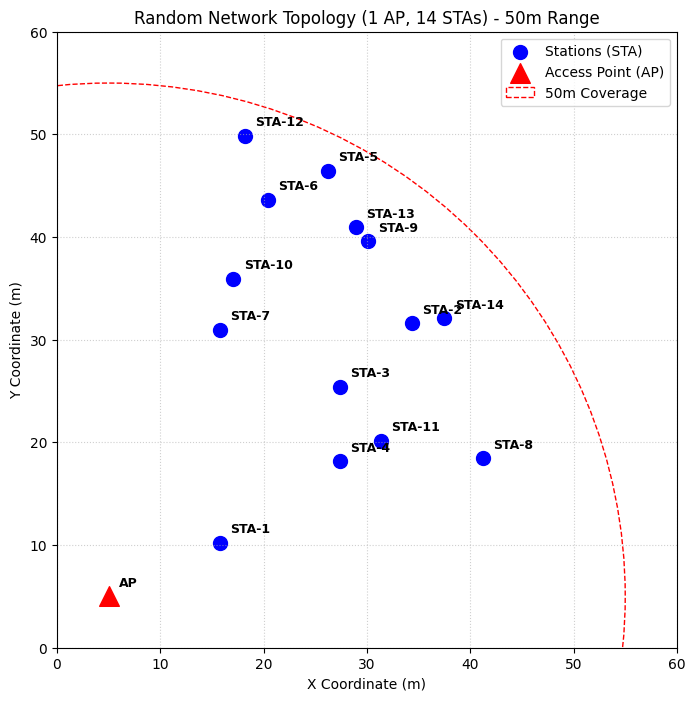

In [ ]:

num_nodes = 15
area_size = 50

# Randomly generate X, Y coordinates for STAs
coords = np.random.uniform(10, area_size, size=(num_nodes-1, 2))
# AP in the corner/center
ap_coord = np.array([[5, 5]])

all_coords = np.vstack((ap_coord, coords))
node_names = ["AP"] + [f"STA-{i}" for i in range(1, num_nodes)]

pos = {name: coord for name, coord in zip(node_names, all_coords)}

# Visualize Topology
plt.figure(figsize=(8, 8))
plt.scatter(all_coords[1:, 0], all_coords[1:, 1], c='blue', s=100, label='Stations (STA)')
plt.scatter(all_coords[0, 0], all_coords[0, 1], c='red', s=200, marker='^', label='Access Point (AP)')

for name, (x, y) in pos.items():
    plt.text(x+1, y+1, name, fontsize=9, fontweight='bold')

# Draw 50m coverage radius from AP
circle = plt.Circle(pos["AP"], max_distance, color='r', fill=False, linestyle='--', label=f'{max_distance}m Coverage')
plt.gca().add_patch(circle)

plt.xlim(0, max_distance + 10)
plt.ylim(0, max_distance + 10)
plt.title("Random Network Topology (1 AP, 14 STAs) - 50m Range")
plt.xlabel("X Coordinate (m)")
plt.ylabel("Y Coordinate (m)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Calculate Distances from AP to all STAs
distances_from_ap = {name: np.linalg.norm(coord - pos["AP"]) for name, coord in pos.items() if name != "AP"}



## 3. Advanced Noise Modeling, Signal Quality & Anti-Jamming
Implementing **Rayleigh Fading** (multipath interference indoors) alongside Gaussian path loss.
Includes **Frequency Hopping Mechanism**: Stations send a 3-bit unique code. Under severe jamming, the AP fails to receive this code and dynamically switches to the 5GHz band to bypass the jamming, incurring a 1-second interruption.


In [ ]:

def get_indoor_path_loss(dist, n_exp, freq_band='2.4GHz'):
    pl_0 = 40 if freq_band == '2.4GHz' else 46 # 5GHz has higher baseline path loss
    return pl_0 + 10 * n_exp * np.log10(dist)

def get_rayleigh_fading_dB():
    # Rayleigh fading power is exponentially distributed
    # H ~ CN(0, 1), |H|^2 ~ Exp(1). 10*log10(|H|^2) gives dB fading
    power_gain = np.random.exponential(1.0)
    # To prevent log(0)
    power_gain = max(power_gain, 1e-10)
    fading_dB = 10 * np.log10(power_gain)
    return fading_dB

def calculate_snr(dist, n_exp, apply_fading=False, extra_noise_dB=0, freq_band='2.4GHz'):
    pl = get_indoor_path_loss(dist, n_exp, freq_band)
    rx_power = tx_power_dBm - pl

    if apply_fading:
        rx_power += get_rayleigh_fading_dB()

    actual_noise = noise_power_dBm + extra_noise_dB
    snr = rx_power - actual_noise
    return snr, rx_power

def map_snr_to_throughput(snr_dB):
    snr_lin = 10 ** (snr_dB / 10)
    best_tp = 0
    best_mode = None
    min_ber = 1.0

    wifi_modes_s2 = [
        ('802.11b', 'BPSK',    1),
        ('802.11b', 'QPSK',    2),
        ('802.11g', '16-QAM', 24),
        ('802.11n', '64-QAM', 54),
    ]

    for std, mod, rate in wifi_modes_s2:
        if mod == 'BPSK':     p_err = ber_bpsk(snr_lin)
        elif mod == 'QPSK':   p_err = ber_qpsk(snr_lin)
        elif mod == '16-QAM': p_err = ber_16qam(snr_lin)
        elif mod == '64-QAM': p_err = ber_64qam(snr_lin)

        tp = rate * (1 - p_err)
        if p_err < 0.05 and tp > best_tp:
            best_tp = tp
            best_mode = f"{std} {mod} ({rate}Mbps)"
            min_ber = p_err

    if best_tp == 0:
        return 0, "No Link", 1.0
    return best_tp, best_mode, min_ber

print("Advanced RF Channel Models + map_snr_to_throughput defined.")


Advanced RF Channel Models + map_snr_to_throughput defined.



## 4. Scenario Simulations & Comparative Analysis
We evaluate all STAs connected to the AP under two distinct scenarios:
1. **Scenario A (Normal Mode)**: Standard indoor path loss (n=3), baseline noise, no fading. AP receives 3-bit STA codes successfully.
2. **Scenario B (Worst-Case / 'War-like' Mode)**: Dense/obstructed environment (n=4), high interference (+15 dB noise), severe fading. The 3-bit code gets lost in jamming, triggering AP to switch to 5GHz, incurring a 1s interrupt but restoring communication without jamming.


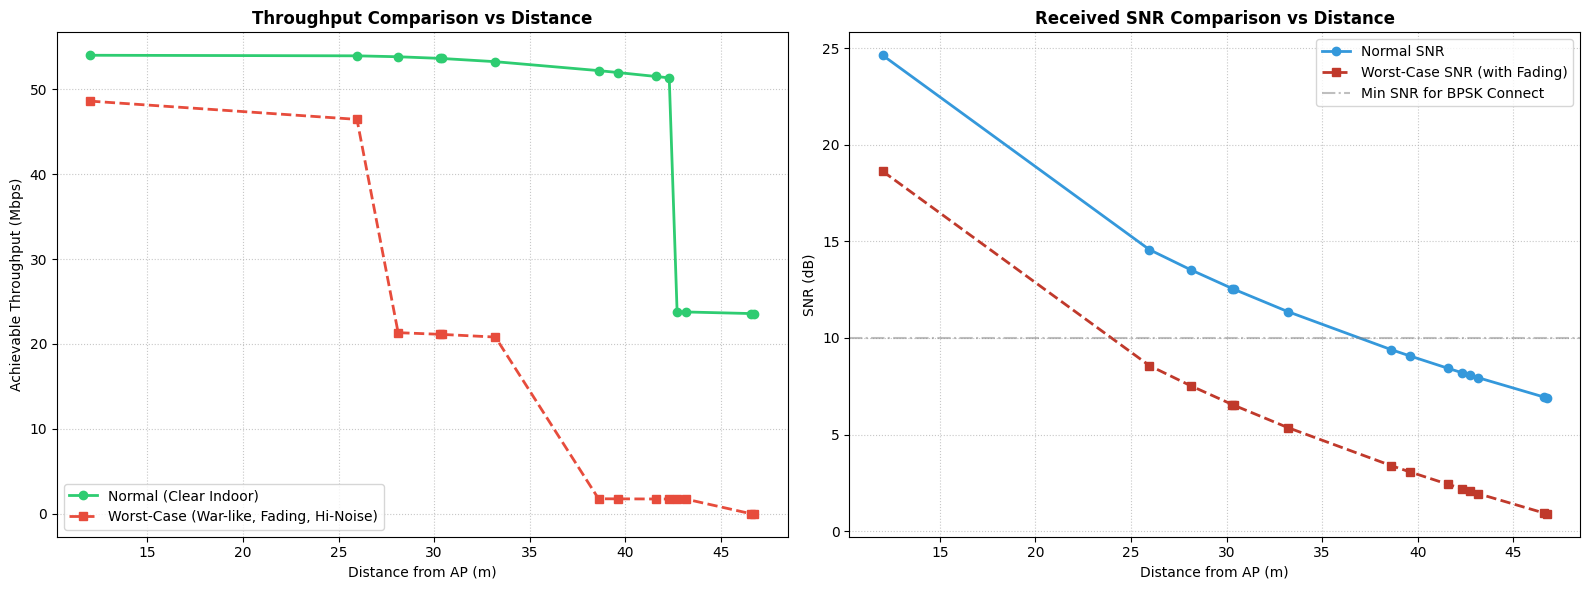

In [ ]:

results_normal = []
results_worst = []

# Generate random 3-bit code for each station
sta_codes = {sta: np.random.randint(0, 8) for sta, dist in distances_from_ap.items()}

simulation_window_time = 10.0 # Define a 10s window to calculate effective throughput drop
interruption_time_s = 1.0 # 1s interruption for switching

for sta, dist in distances_from_ap.items():
    code = sta_codes[sta]

    # Normal Scenario (2.4GHz)
    snr_norm, _ = calculate_snr(dist, n_exp=3, apply_fading=False, extra_noise_dB=0, freq_band='2.4GHz')
    tp_norm, mode_norm, ber_norm = map_snr_to_throughput(snr_norm)
    results_normal.append((sta, dist, snr_norm, tp_norm, ber_norm))

    # Worst-Case Scenario (Jamming at 2.4GHz)
    snr_jam, _ = calculate_snr(dist, n_exp=4, apply_fading=True, extra_noise_dB=15, freq_band='2.4GHz')

    # Check if 3-bit code was received (assuming heavily jammed if SNR < 5)
    if snr_jam < 5:
        # Code not received, trigger switch to 5GHz to evade jamming
        snr_worst, _ = calculate_snr(dist, n_exp=3, apply_fading=False, extra_noise_dB=0, freq_band='5GHz')
        tp_worst, mode_worst, ber_worst = map_snr_to_throughput(snr_worst)

        # Apply 1s interruption penalty to throughput
        effective_tp = tp_worst * ((simulation_window_time - interruption_time_s) / simulation_window_time)
        mode_worst += " (5GHz Switch)"
    else:
        # Code received somehow, process normally under jamming
        tp_worst, mode_worst, ber_worst = map_snr_to_throughput(snr_jam)
        effective_tp = tp_worst
        snr_worst = snr_jam

    results_worst.append((sta, dist, snr_worst, effective_tp, ber_worst))

# Sort by distance for cleaner plotting
results_normal.sort(key=lambda x: x[1])
results_worst.sort(key=lambda x: x[1])

distances = [r[1] for r in results_normal]
tp_n = [r[3] for r in results_normal]
tp_w = [r[3] for r in results_worst]
snr_n = [r[2] for r in results_normal]
snr_w = [r[2] for r in results_worst]

# --- PLOTTING COMPARATIVE ANALYSIS ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Throughput Comparison
axes[0].plot(distances, tp_n, 'o-', color='#2ecc71', lw=2, label='Normal (Clear Indoor)')
axes[0].plot(distances, tp_w, 's--', color='#e74c3c', lw=2, label='Worst-Case (War-like, Fading, Hi-Noise)')
axes[0].set_title("Throughput Comparison vs Distance", fontweight='bold')
axes[0].set_xlabel("Distance from AP (m)")
axes[0].set_ylabel("Achievable Throughput (Mbps)")
axes[0].grid(True, linestyle=':', alpha=0.7)
axes[0].legend()

# SNR Comparison
axes[1].plot(distances, snr_n, 'o-', color='#3498db', lw=2, label='Normal SNR')
axes[1].plot(distances, snr_w, 's--', color='#c0392b', lw=2, label='Worst-Case SNR (with Fading)')
axes[1].axhline(y=10, color='gray', linestyle='-.', alpha=0.5, label='Min SNR for BPSK Connect')
axes[1].set_title("Received SNR Comparison vs Distance", fontweight='bold')
axes[1].set_xlabel("Distance from AP (m)")
axes[1].set_ylabel("SNR (dB)")
axes[1].grid(True, linestyle=':', alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()



## 5. Quantitative Summary
Reviewing the network availability and performance drop under extreme conditions.


In [ ]:

connected_normal = sum(1 for tp in tp_n if tp > 0)
connected_worst = sum(1 for tp in tp_w if tp > 0)

avg_tp_norm = np.mean(tp_n)
avg_tp_worst = np.mean([tp for tp in tp_w])

print("="*60)
print("NETWORK SURVIVABILITY REPORT : NORMAL vs WORST-CASE")
print("="*60)
print(f"Total Stations       : {num_nodes - 1}")
print(f"Max Range Tested     : {max_distance} meters")
print("-" * 60)
print(f"[NORMAL]      Connected Relays : {connected_normal} / {num_nodes-1}")
print(f"[NORMAL]      Avg Throughput   : {avg_tp_norm:.2f} Mbps")
print("-" * 60)
print(f"[WORST-CASE]  Connected Relays : {connected_worst} / {num_nodes-1}")
print(f"[WORST-CASE]  Avg Throughput   : {avg_tp_worst:.2f} Mbps")
print("="*60)

if connected_worst < connected_normal:
    drop_pct = (1 - (connected_worst/connected_normal)) * 100
    print(f"CONCLUSION: Severe conditions caused a {drop_pct:.1f}% drop in node connectivity.")
    print(f"Total Network Throughput capacity reduced by {((avg_tp_norm - avg_tp_worst)/max(1,avg_tp_norm))*100:.1f}%")



NETWORK SURVIVABILITY REPORT : NORMAL vs WORST-CASE
Total Stations       : 14
Max Range Tested     : 50 meters
------------------------------------------------------------
[NORMAL]      Connected Relays : 14 / 14
[NORMAL]      Avg Throughput   : 44.57 Mbps
------------------------------------------------------------
[WORST-CASE]  Connected Relays : 12 / 14
[WORST-CASE]  Avg Throughput   : 13.57 Mbps
CONCLUSION: Severe conditions caused a 14.3% drop in node connectivity.
Total Network Throughput capacity reduced by 69.6%
